# Topic 2 — SVM vs Random Forest

**Q1:** Breast Cancer Wisconsin
**Q2:** Wine Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

---
## Question 1 — Breast Cancer Wisconsin

### Step 1: Load, inspect, clean

In [2]:
df = pd.read_csv("datasets/breast-cancer-wisconsin.csv")
df = df.replace("?", np.nan).drop(columns=["id"]).astype(float)
df = df.fillna(df.median())

print("Shape          :", df.shape)
print("Missing values :", df.isna().sum().sum())
print("\nClass distribution (2 = benign, 4 = malignant):\n", df["class"].value_counts())
df.head()

Shape          : (699, 10)
Missing values : 0

Class distribution (2 = benign, 4 = malignant):
 class
2.0    458
4.0    241
Name: count, dtype: int64


,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,2.0
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,2.0
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,2.0
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,2.0


### Step 2: EDA — class distribution + two feature distributions

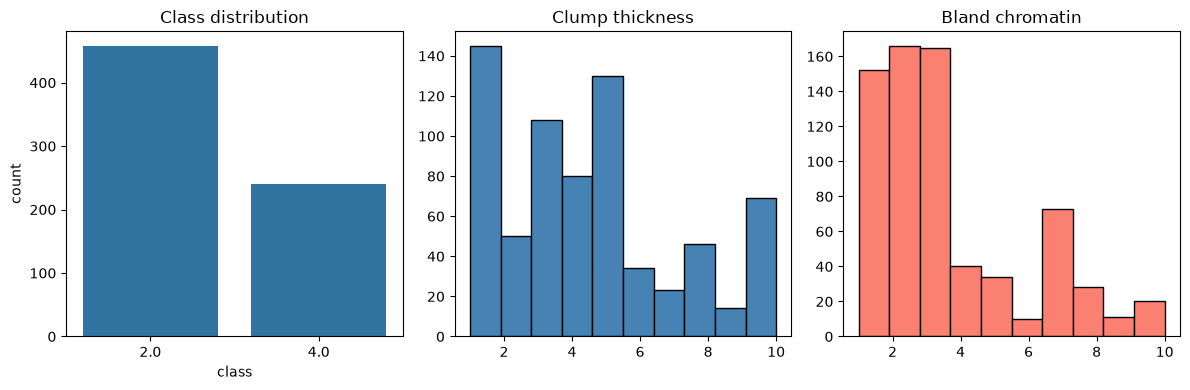

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="class", data=df)
plt.title("Class distribution")

plt.subplot(1, 3, 2)
plt.hist(df["clump_thickness"], bins=10, color="steelblue", edgecolor="black")
plt.title("Clump thickness")

plt.subplot(1, 3, 3)
plt.hist(df["bland_chromatin"], bins=10, color="salmon", edgecolor="black")
plt.title("Bland chromatin")

plt.tight_layout()
plt.show()

### Step 3: Split and scale

SVM is distance-based, so it **needs** scaling. Random Forest is a tree model, so scaling
does not matter for it — it can be trained on the raw features.

In [4]:
X = df.drop(columns=["class"])
y = (df["class"] == 4).astype(int)      # 1 = malignant

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

### Step 4: Train and evaluate both models

In [5]:
def train_eval(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    scores = {"Model": name,
              "Accuracy": accuracy_score(yte, pred),
              "Precision": precision_score(yte, pred),
              "Recall": recall_score(yte, pred),
              "F1": f1_score(yte, pred)}
    return scores, confusion_matrix(yte, pred)


svm_scores, svm_cm = train_eval("SVM (RBF)", SVC(kernel="rbf", random_state=42),
                                X_train_s, X_test_s, y_train, y_test)
rf_scores, rf_cm = train_eval("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42),
                              X_train, X_test, y_train, y_test)

results = pd.DataFrame([svm_scores, rf_scores]).round(4)
results

,Model,Accuracy,Precision,Recall,F1
0,SVM (RBF),0.9571,0.9375,0.9375,0.9375
1,Random Forest,0.9500,0.9184,0.9375,0.9278


### Step 5: 5-fold cross-validation (more reliable than a single split)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all_scaled = StandardScaler().fit_transform(X)
svm_cv = cross_val_score(SVC(kernel="rbf"), X_all_scaled, y, cv=cv)
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=cv)

print("SVM  5-fold accuracy: %.4f (+/- %.4f)" % (svm_cv.mean(), svm_cv.std()))
print("RF   5-fold accuracy: %.4f (+/- %.4f)" % (rf_cv.mean(), rf_cv.std()))

SVM  5-fold accuracy: 0.9642 (+/- 0.0046)
RF   5-fold accuracy: 0.9657 (+/- 0.0095)


### Step 6: Confusion matrices, feature importance, comparison

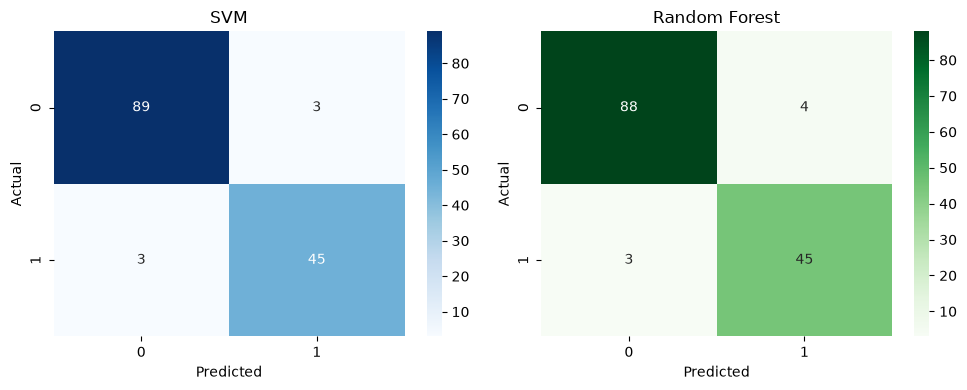

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.tight_layout()
plt.show()

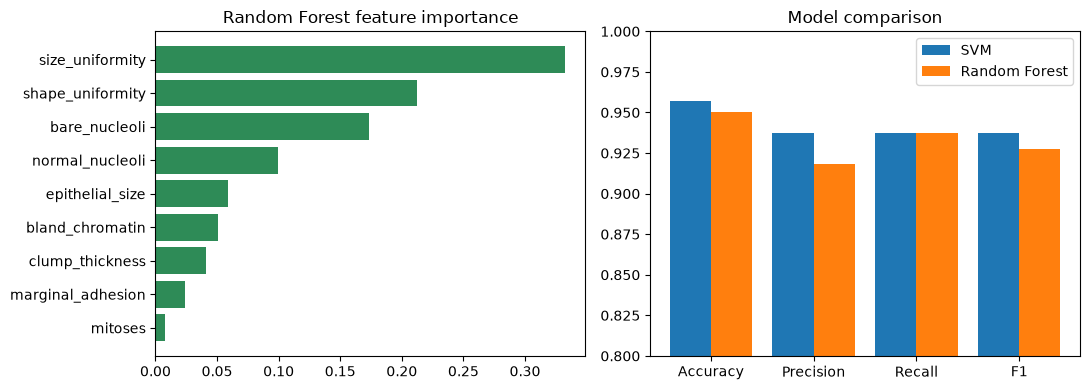

Better model (by F1-score): SVM (RBF)


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.barh(importance.index, importance.values, color="seagreen")
plt.title("Random Forest feature importance")

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))
plt.subplot(1, 2, 2)
plt.bar(x - 0.2, results.loc[0, metrics], width=0.4, label="SVM")
plt.bar(x + 0.2, results.loc[1, metrics], width=0.4, label="Random Forest")
plt.xticks(x, metrics); plt.ylim(0.8, 1.0); plt.legend()
plt.title("Model comparison")

plt.tight_layout()
plt.show()

print("Better model (by F1-score):", results.loc[results["F1"].idxmax(), "Model"])

**Conclusion (Q1).** Both models reach roughly 95–96% accuracy and the 5-fold CV scores are almost
identical. The dataset is small, clean and nearly linearly separable, so a well-scaled SVM finds a
good margin easily. Random Forest additionally tells us *which* features matter
(`size_uniformity`, `shape_uniformity`, `bare_nucleoli` dominate).

---
## Question 2 — Wine Quality

### Step 1: Load, inspect, build classes

In [9]:
wine = pd.read_csv("datasets/WineQT.csv").drop(columns=["Id"])
print("Shape          :", wine.shape)
print("Missing values :", wine.isna().sum().sum())

def to_class(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

wine["quality_class"] = wine["quality"].apply(to_class)
print("\nClass distribution:\n", wine["quality_class"].value_counts())
wine.head()

Shape          : (1143, 12)
Missing values : 0

Class distribution:
 quality_class
low       522
medium    462
high      159
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,low


### Step 2: EDA — class distribution and numerical feature distributions

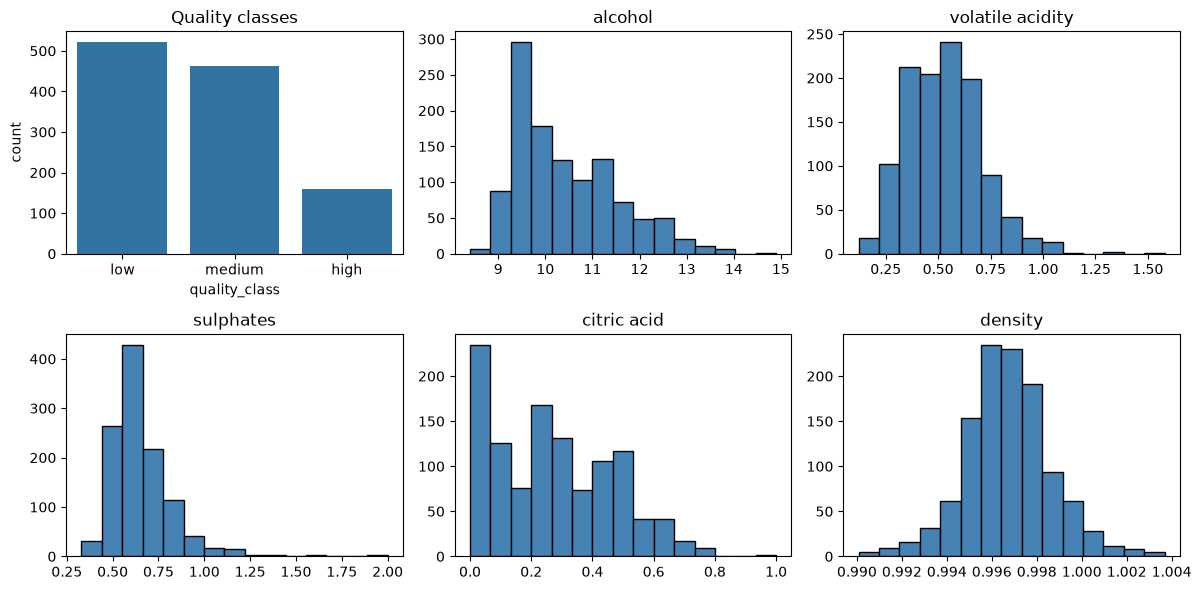

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
sns.countplot(x="quality_class", data=wine, order=["low", "medium", "high"])
plt.title("Quality classes")

for i, col in enumerate(["alcohol", "volatile acidity", "sulphates", "citric acid", "density"]):
    plt.subplot(2, 3, i + 2)
    plt.hist(wine[col], bins=15, color="steelblue", edgecolor="black")
    plt.title(col)

plt.tight_layout()
plt.show()

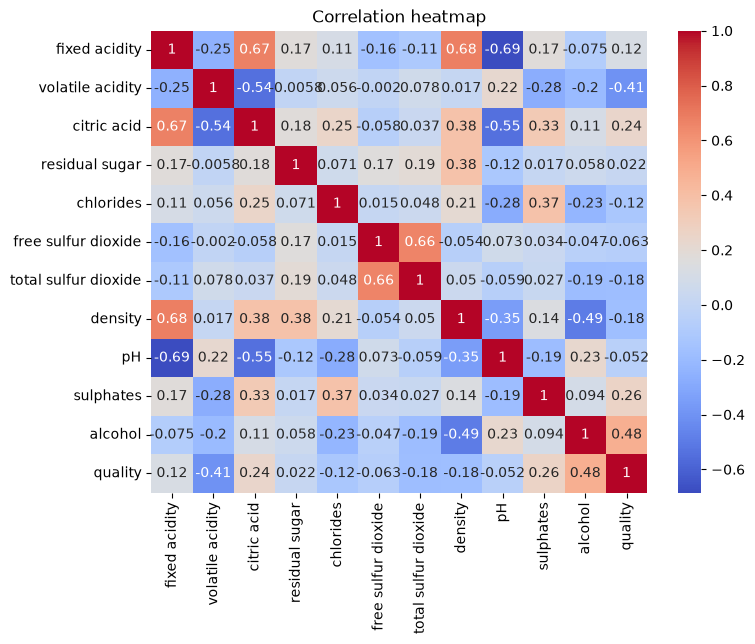

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(wine.drop(columns=["quality_class"]).corr(), cmap="coolwarm", annot=True)
plt.title("Correlation heatmap")
plt.show()

### Step 3: Split + scaling (SVM only)

In [12]:
X = wine.drop(columns=["quality", "quality_class"])
y = wine["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

### Step 4: Train and evaluate

In [13]:
labels = ["low", "medium", "high"]

def train_eval_multi(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    scores = {"Model": name,
              "Accuracy": accuracy_score(yte, pred),
              "Precision": precision_score(yte, pred, average="weighted", zero_division=0),
              "Recall": recall_score(yte, pred, average="weighted"),
              "F1": f1_score(yte, pred, average="weighted")}
    return scores, confusion_matrix(yte, pred, labels=labels)


svm_scores, svm_cm = train_eval_multi("SVM (RBF)", SVC(kernel="rbf", random_state=42),
                                      X_train_s, X_test_s, y_train, y_test)
rf_scores, rf_cm = train_eval_multi("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42),
                                    X_train, X_test, y_train, y_test)

results = pd.DataFrame([svm_scores, rf_scores]).round(4)
results

,Model,Accuracy,Precision,Recall,F1
0,SVM (RBF),0.6463,0.6485,0.6463,0.6390
1,Random Forest,0.6987,0.7057,0.6987,0.7003


### Step 5: Confusion matrices and comparison

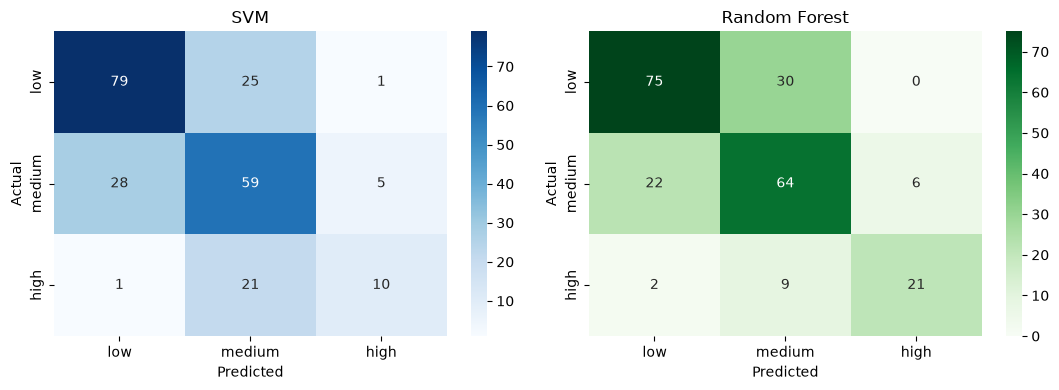

In [14]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("SVM"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Random Forest"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.tight_layout()
plt.show()

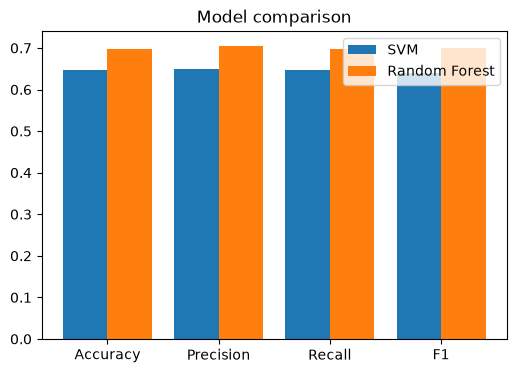

Better model: Random Forest


In [15]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))
plt.bar(x - 0.2, results.loc[0, metrics], width=0.4, label="SVM")
plt.bar(x + 0.2, results.loc[1, metrics], width=0.4, label="Random Forest")
plt.xticks(x, metrics)
plt.title("Model comparison")
plt.legend()
plt.show()

print("Better model:", results.loc[results["F1"].idxmax(), "Model"])

**Conclusion (Q2).** Random Forest wins (~0.70 vs ~0.65 accuracy). Why:

1. The wine classes overlap heavily — no clean margin exists, which is exactly the situation SVM
   struggles with.
2. Random Forest splits on thresholds of individual features (e.g. `alcohol > 10.5`), which suits
   these physicochemical measurements, and averaging many trees handles the noisy, imbalanced data
   better.
3. The `high` class is the smallest, so both models misclassify it most often — visible in the
   confusion matrices.